In [37]:
import pandas as pd
url = 'https://raw.githubusercontent.com/EvaW01/schulich_data_science_Xinyue-Wang/refs/heads/main/grocery_synthetic_data.csv'
df = pd.read_csv(url)

In [38]:
df.head()

,product_id,product_name,product_price,average_weight_kg,product_category,customer_id,customer_name,product_count,total_amount,historical_amount,customer_start_date,last_transaction_date,transaction_id,transaction_amount,transaction_time
0,48443,Tortilla(6pck),5.0,0.30,Bakery,359816,Kylie Davis,4,20.0,20.0,5/28/2023,5/6/2024,61a6721c-a04b-46f7-81f0-27dd35b5733d,20.0,5/6/2024 10:53
1,44817,White Bread,4.0,0.50,Bakery,972886,Delina Ivanova,3,12.0,12.0,10/11/2021,8/15/2024,39b6d3f7-6f88-4b4c-9e24-4d32f9e7d5be,12.0,8/15/2024 6:56
2,60571,Tomato Ketchup,5.5,0.75,Sauce,121533,John Castillo,3,16.5,16.5,2/15/2023,11/3/2024,67591a5b-8291-43ba-b8fe-62a6ca4368bb,16.5,11/3/2024 3:40
3,55644,Beef,18.0,1.00,Meat,121533,John Castillo,2,36.0,16.5,2/15/2023,11/3/2024,60102540-053b-41f0-973c-27c463e6724b,36.0,8/21/2024 17:59
4,67243,Shredded Cheese(350g),7.0,0.35,Dairy,703094,Leslie Pitts,3,21.0,21.0,3/15/2021,9/20/2024,d578721e-7626-4899-befc-4bc8dc0dd06c,21.0,9/20/2024 10:29


In [39]:
print(df.isnull().sum())

product_id               0
product_name             0
product_price            0
average_weight_kg        0
product_category         0
customer_id              0
customer_name            0
product_count            0
total_amount             0
historical_amount        0
customer_start_date      0
last_transaction_date    0
transaction_id           0
transaction_amount       0
transaction_time         0
dtype: int64


In [40]:
df['customer_start_date'] = pd.to_datetime(df['customer_start_date'])
df['last_transaction_date'] = pd.to_datetime(df['last_transaction_date'])
df['transaction_time'] = pd.to_datetime(df['transaction_time'])

In [41]:
# Group by customer and transaction date
transaction_based = df.groupby(['customer_id', 'customer_name', 'last_transaction_date']).agg({
    'product_name': lambda x: ', '.join(x),  # Combine product names
    'product_count': 'sum',  # Sum product counts for the transaction
    'total_amount': 'sum',  # Sum total amount for the transaction
    'transaction_id': lambda x: ', '.join(x),  # Combine transaction IDs
}).reset_index()

# Rename columns for clarity
transaction_based.rename(columns={
    'product_name': 'products_purchased',
    'product_count': 'total_products_count',
    'total_amount': 'total_spent',
    'last_transaction_date': 'transaction_date',
    'transaction_id': 'transaction_ids',
}, inplace=True)

# Save to CSV or print (alternative to ace_tools)
transaction_based

,customer_id,customer_name,transaction_date,products_purchased,total_products_count,total_spent,transaction_ids
0,121533,John Castillo,2024-11-03,"Tomato Ketchup, Beef, Tortilla(10pck), Brown B...",21,129.75,"67591a5b-8291-43ba-b8fe-62a6ca4368bb, 60102540..."
1,121533,John Castillo,2024-11-07,"Eggs(1.5dozen), Shredded Cheese(350g), Cookies...",62,383.75,"52c9f66f-77f9-46b7-a2c6-9053b03dfea2, 2339f377..."
2,121533,John Castillo,2024-11-25,"Mustard, Eggs(0.5dozen), Cupcakes(6pck), Eggs(...",11,58.00,"8dfa737b-b1b3-47e1-9d38-eaeae767d6b3, 60c11c76..."
3,178094,Beth King,2024-11-12,"Mushrooms(500g), Onions(5pck), Mushrooms(500g)...",25,186.25,"d9515b3f-b7d8-4e07-aff2-5f2506292b0e, e172e1de..."
4,178094,Beth King,2024-11-22,"Peanut Butter, Peanut Butter, Eggs(1dozen), Ri...",55,357.75,"5791b545-9aa9-4434-95d5-9103b6292ee6, dd5676dc..."
...,...,...,...,...,...,...,...
101,999944,Cory Simpson,2024-10-11,"Mustard, Mustard, Chicken, Butter(550g), Straw...",36,223.75,"1cc79f62-a7b9-4478-9e70-49e32de2ae72, cd5dffec..."
102,999944,Cory Simpson,2024-11-09,"Cookies, Eggs(1.5dozen), Pork, Bananas(6pck), ...",13,89.50,"fa8b44d4-faac-44e9-af19-8499faf5e6d3, 36495750..."
103,999944,Cory Simpson,2024-11-11,"Cereal, Mustard, Cereal, Mustard",14,59.00,"b3adcaf0-9db0-4a72-b990-41d5a2957217, d7890ba2..."
104,999944,Cory Simpson,2024-11-13,"Bananas(6pck), Mushrooms(500g)",6,29.25,"2611dd8b-ab9c-4fb1-93d1-84deac643b80, 036d0920..."


In [42]:
df.describe()

,product_id,product_price,average_weight_kg,customer_id,product_count,total_amount,historical_amount,customer_start_date,last_transaction_date,transaction_amount,transaction_time
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000,1000.000000,1000
mean,57663.930000,6.723250,0.665230,587230.907000,2.419000,16.199750,16.273500,2021-12-14 23:22:33.599999744,2024-10-31 16:09:07.200000,16.199750,2024-06-18 09:30:55.440000
min,10873.000000,3.750000,0.250000,121533.000000,1.000000,3.750000,3.750000,2019-12-03 00:00:00,2024-01-02 00:00:00,3.750000,2024-01-01 00:54:00
25%,38954.000000,4.500000,0.350000,355050.000000,1.000000,7.500000,7.500000,2020-12-05 00:00:00,2024-11-03 00:00:00,7.500000,2024-03-29 11:30:30
50%,55786.000000,5.000000,0.500000,632553.000000,3.000000,15.750000,15.750000,2021-10-11 00:00:00,2024-11-14 00:00:00,15.750000,2024-06-18 05:25:30
75%,74097.000000,7.000000,0.800000,803204.000000,3.000000,19.500000,19.500000,2023-04-06 00:00:00,2024-11-22 00:00:00,19.500000,2024-09-13 02:18:00
max,99196.000000,18.000000,4.000000,999944.000000,4.000000,64.000000,64.000000,2023-09-17 00:00:00,2024-11-27 00:00:00,64.000000,2024-11-27 18:16:00
std,26867.404547,3.892123,0.600123,271052.019119,1.076382,12.193768,12.213686,NaN,NaN,12.193768,NaN


In [43]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   product_id             1000 non-null   int64         
 1   product_name           1000 non-null   object        
 2   product_price          1000 non-null   float64       
 3   average_weight_kg      1000 non-null   float64       
 4   product_category       1000 non-null   object        
 5   customer_id            1000 non-null   int64         
 6   customer_name          1000 non-null   object        
 7   product_count          1000 non-null   int64         
 8   total_amount           1000 non-null   float64       
 9   historical_amount      1000 non-null   float64       
 10  customer_start_date    1000 non-null   datetime64[ns]
 11  last_transaction_date  1000 non-null   datetime64[ns]
 12  transaction_id         1000 non-null   object        
 13  tran

In [44]:
df.columns

Index(['product_id', 'product_name', 'product_price', 'average_weight_kg',
       'product_category', 'customer_id', 'customer_name', 'product_count',
       'total_amount', 'historical_amount', 'customer_start_date',
       'last_transaction_date', 'transaction_id', 'transaction_amount',
       'transaction_time'],
      dtype='object')

In [45]:
df.nunique()

product_id                 34
product_name               34
product_price              18
average_weight_kg          15
product_category            8
customer_id                24
customer_name              24
product_count               4
total_amount               26
historical_amount          26
customer_start_date        24
last_transaction_date      76
transaction_id           1000
transaction_amount         26
transaction_time          999
dtype: int64

In [46]:
print(df.groupby('customer_name')['last_transaction_date'].nunique() == 1)


customer_name
Abhinav Vig        False
Alison Williams    False
Beth King          False
Cory Simpson       False
Delina Ivanova     False
Elizabeth Brown    False
Emily Bryant       False
Eric Patterson     False
James Saunders     False
Jeffrey Jordan     False
John Castillo      False
Kim Scott          False
Kylie Davis        False
Leslie Pitts       False
Matthew Gordon     False
Michael Morales    False
Michael Romero     False
Micheal Case       False
Muskan Sekhri      False
Neeraj Nagula      False
Richard Barnes      True
Sandra Gibson      False
Selvin Furtado     False
Xinyue Wang        False
Name: last_transaction_date, dtype: bool


In [47]:
# check how many different last transaction dates each customer has
visit_times = df.groupby('customer_name')['last_transaction_date'].nunique()
visit_times

customer_name
Abhinav Vig        3
Alison Williams    5
Beth King          2
Cory Simpson       6
Delina Ivanova     8
Elizabeth Brown    5
Emily Bryant       6
Eric Patterson     3
James Saunders     4
Jeffrey Jordan     6
John Castillo      3
Kim Scott          2
Kylie Davis        6
Leslie Pitts       4
Matthew Gordon     2
Michael Morales    6
Michael Romero     8
Micheal Case       3
Muskan Sekhri      8
Neeraj Nagula      2
Richard Barnes     1
Sandra Gibson      5
Selvin Furtado     3
Xinyue Wang        5
Name: last_transaction_date, dtype: int64

In [48]:
df_customer_total_amount = df.groupby(['customer_name'])['total_amount'].sum().reset_index()
df_customer_total_amount

,customer_name,total_amount
0,Abhinav Vig,918.50
1,Alison Williams,594.00
2,Beth King,544.00
3,Cory Simpson,810.25
4,Delina Ivanova,719.75
5,Elizabeth Brown,612.50
6,Emily Bryant,770.75
7,Eric Patterson,730.25
8,James Saunders,722.75
9,Jeffrey Jordan,393.25


In [49]:
df_customer_total_amount_by_date = df.groupby(['customer_name', 'last_transaction_date'])['total_amount'].sum().reset_index()
df_customer_total_amount_by_date

,customer_name,last_transaction_date,total_amount
0,Abhinav Vig,2024-01-02,64.00
1,Abhinav Vig,2024-10-12,63.50
2,Abhinav Vig,2024-11-23,791.00
3,Alison Williams,2024-04-04,4.50
4,Alison Williams,2024-05-21,24.75
...,...,...,...
101,Xinyue Wang,2024-05-17,24.50
102,Xinyue Wang,2024-07-13,26.50
103,Xinyue Wang,2024-08-26,179.25
104,Xinyue Wang,2024-11-17,319.25


In [50]:
customer_product_types = df.groupby(['customer_name', 'last_transaction_date'])['product_id'].nunique()
customer_product_types

customer_name    last_transaction_date
Abhinav Vig      2024-01-02                1
                 2024-10-12                3
                 2024-11-23               26
Alison Williams  2024-04-04                1
                 2024-05-21                3
                                          ..
Xinyue Wang      2024-05-17                2
                 2024-07-13                3
                 2024-08-26                7
                 2024-11-17               15
                 2024-11-18                1
Name: product_id, Length: 106, dtype: int64

In [51]:
customer_product_category = df.groupby(['customer_name', 'last_transaction_date'])['product_category'].nunique()
customer_product_category

customer_name    last_transaction_date
Abhinav Vig      2024-01-02               1
                 2024-10-12               2
                 2024-11-23               8
Alison Williams  2024-04-04               1
                 2024-05-21               3
                                         ..
Xinyue Wang      2024-05-17               2
                 2024-07-13               3
                 2024-08-26               5
                 2024-11-17               8
                 2024-11-18               1
Name: product_category, Length: 106, dtype: int64

In [52]:
# 获取每个客户最近一次的购买时间
df_last_purchase = df.groupby('customer_name')['last_transaction_date'].max().reset_index()
df_last_purchase

,customer_name,last_transaction_date
0,Abhinav Vig,2024-11-23
1,Alison Williams,2024-11-12
2,Beth King,2024-11-22
3,Cory Simpson,2024-11-21
4,Delina Ivanova,2024-11-20
5,Elizabeth Brown,2024-11-27
6,Emily Bryant,2024-11-11
7,Eric Patterson,2024-11-14
8,James Saunders,2024-11-26
9,Jeffrey Jordan,2024-11-12


In [53]:
# Merge all aggregated data into a single DataFrame
df_merged = df_customer_total_amount_by_date.copy()

# Add unique products count
df_merged = df_merged.merge(customer_product_types.reset_index(name='unique_products_count'), 
                            on=['customer_name', 'last_transaction_date'], how='left')

# Add unique product categories count
df_merged = df_merged.merge(customer_product_category.reset_index(name='unique_categories_count'), 
                            on=['customer_name', 'last_transaction_date'], how='left')

# Add visit times per customer
df_merged['visit_times'] = df_merged['customer_name'].map(visit_times)

# Add day of the week as a feature
df_merged['transaction_day_of_week'] = pd.to_datetime(df_merged['last_transaction_date']).dt.dayofweek

# Add days since last transaction (time delta)
df_merged['last_transaction_date'] = pd.to_datetime(df_merged['last_transaction_date'])
df_merged['days_since_last_transaction'] = df_merged.groupby('customer_name')['last_transaction_date'].diff().dt.days
df_merged['days_since_last_transaction'].fillna(0, inplace=True)

# Preview the final table
df_merged


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27880\3476269513.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged['days_since_last_transaction'].fillna(0, inplace=True)


,customer_name,last_transaction_date,total_amount,unique_products_count,unique_categories_count,visit_times,transaction_day_of_week,days_since_last_transaction
0,Abhinav Vig,2024-01-02,64.00,1,1,3,1,0.0
1,Abhinav Vig,2024-10-12,63.50,3,2,3,5,284.0
2,Abhinav Vig,2024-11-23,791.00,26,8,3,5,42.0
3,Alison Williams,2024-04-04,4.50,1,1,5,3,0.0
4,Alison Williams,2024-05-21,24.75,3,3,5,1,47.0
...,...,...,...,...,...,...,...,...
101,Xinyue Wang,2024-05-17,24.50,2,2,5,4,0.0
102,Xinyue Wang,2024-07-13,26.50,3,3,5,5,57.0
103,Xinyue Wang,2024-08-26,179.25,7,5,5,0,44.0
104,Xinyue Wang,2024-11-17,319.25,15,8,5,6,83.0


In [54]:
# Step 1: Pivot for products
product_pivot = df.pivot_table(
    index=['customer_name', 'last_transaction_date'],
    columns='product_name',
    values='product_count',
    aggfunc='sum',
    fill_value=0
).reset_index()

# Step 2: Pivot for categories
category_pivot = df.pivot_table(
    index=['customer_name', 'last_transaction_date'],
    columns='product_category',
    values='product_count',
    aggfunc='sum',
    fill_value=0
).reset_index()

# Step 3: Merge all relevant tables
df_expanded = df_customer_total_amount_by_date.copy()

# Merge product data
df_expanded = df_expanded.merge(product_pivot, on=['customer_name', 'last_transaction_date'], how='left')

# Merge category data
df_expanded = df_expanded.merge(category_pivot, on=['customer_name', 'last_transaction_date'], how='left')

# Fill NaN values after the merge (if any)
df_expanded.fillna(0, inplace=True)

# Display the first few rows of the expanded table to ensure everything is correct
df_expanded.head()


,customer_name,last_transaction_date,total_amount,Apples(5pck),Bananas(6pck),Beef,Biscuits,Brown Bread,Butter(350g),Butter(550g),...,Tortilla(6pck),White Bread,Bakery,Dairy,Fruits,Grains,Meat,Sauce,Snacks,Vegetables
0,Abhinav Vig,2024-01-02,64.00,0,0,0,0,0,0,0,...,0,0,0,0,0,0,4,0,0,0
1,Abhinav Vig,2024-10-12,63.50,0,0,0,0,0,0,0,...,4,6,10,3,0,0,0,0,0,0
2,Abhinav Vig,2024-11-23,791.00,2,6,6,4,8,9,6,...,4,9,25,28,8,1,15,6,25,8
3,Alison Williams,2024-04-04,4.50,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,Alison Williams,2024-05-21,24.75,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,3,0,1


In [55]:
# Merge df_merged and df_expanded into a single DataFrame named df_model
df_model = df_merged.merge(df_expanded, on=['customer_name', 'last_transaction_date'], how='inner')

# Display the structure of the merged DataFrame
df_model.head()


,customer_name,last_transaction_date,total_amount_x,unique_products_count,unique_categories_count,visit_times,transaction_day_of_week,days_since_last_transaction,total_amount_y,Apples(5pck),...,Tortilla(6pck),White Bread,Bakery,Dairy,Fruits,Grains,Meat,Sauce,Snacks,Vegetables
0,Abhinav Vig,2024-01-02,64.00,1,1,3,1,0.0,64.00,0,...,0,0,0,0,0,0,4,0,0,0
1,Abhinav Vig,2024-10-12,63.50,3,2,3,5,284.0,63.50,0,...,4,6,10,3,0,0,0,0,0,0
2,Abhinav Vig,2024-11-23,791.00,26,8,3,5,42.0,791.00,2,...,4,9,25,28,8,1,15,6,25,8
3,Alison Williams,2024-04-04,4.50,1,1,5,3,0.0,4.50,0,...,0,0,0,1,0,0,0,0,0,0
4,Alison Williams,2024-05-21,24.75,3,3,5,1,47.0,24.75,0,...,0,0,1,0,0,0,0,3,0,1


In [56]:
# Remove one of the 'total_amount' columns and rename the remaining one
if 'total_amount_x' in df_model.columns and 'total_amount_y' in df_model.columns:
    df_model['total_amount'] = df_model['total_amount_x']  # Retain total_amount_x (or change to total_amount_y if preferred)
    df_model.drop(['total_amount_x', 'total_amount_y'], axis=1, inplace=True)

# Display the updated structure of the merged DataFrame
df_model.head()


,customer_name,last_transaction_date,unique_products_count,unique_categories_count,visit_times,transaction_day_of_week,days_since_last_transaction,Apples(5pck),Bananas(6pck),Beef,...,White Bread,Bakery,Dairy,Fruits,Grains,Meat,Sauce,Snacks,Vegetables,total_amount
0,Abhinav Vig,2024-01-02,1,1,3,1,0.0,0,0,0,...,0,0,0,0,0,4,0,0,0,64.00
1,Abhinav Vig,2024-10-12,3,2,3,5,284.0,0,0,0,...,6,10,3,0,0,0,0,0,0,63.50
2,Abhinav Vig,2024-11-23,26,8,3,5,42.0,2,6,6,...,9,25,28,8,1,15,6,25,8,791.00
3,Alison Williams,2024-04-04,1,1,5,3,0.0,0,0,0,...,0,0,1,0,0,0,0,0,0,4.50
4,Alison Williams,2024-05-21,3,3,5,1,47.0,0,0,0,...,0,1,0,0,0,0,3,0,1,24.75


In [57]:
df_model.columns

Index(['customer_name', 'last_transaction_date', 'unique_products_count',
       'unique_categories_count', 'visit_times', 'transaction_day_of_week',
       'days_since_last_transaction', 'Apples(5pck)', 'Bananas(6pck)', 'Beef',
       'Biscuits', 'Brown Bread', 'Butter(350g)', 'Butter(550g)', 'Cereal',
       'Cheese(14pckts)', 'Chicken', 'Chocolates', 'Cookies', 'Cupcakes(6pck)',
       'Eggs(0.5dozen)', 'Eggs(1.5dozen)', 'Eggs(1dozen)', 'Hot Sauce',
       'Mayonnaise', 'Mushrooms(350g)', 'Mushrooms(500g)', 'Mustard',
       'Onions(5pck)', 'Pasta', 'Peanut Butter', 'Pork', 'Rice(2kg)',
       'Rice(4kg)', 'Shredded Cheese(350g)', 'Shredded Cheese(620g)',
       'Strawberry Jam', 'Tomato Ketchup', 'Tortilla(10pck)', 'Tortilla(6pck)',
       'White Bread', 'Bakery', 'Dairy', 'Fruits', 'Grains', 'Meat', 'Sauce',
       'Snacks', 'Vegetables', 'total_amount'],
      dtype='object')

In [58]:
# 分组并动态划分训练集和测试集
def split_train_test(data):
    test_idx = data['last_transaction_date'].idxmax()  # 保留最后一条记录
    return test_idx

# 获取所有客户的测试集索引
test_indices = df_model.groupby('customer_name').apply(split_train_test).values

# 创建测试集
test_data = df_model.loc[test_indices]

# 创建训练集
train_data = df_model.drop(test_indices)


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27880\1723199447.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_indices = df_model.groupby('customer_name').apply(split_train_test).values


In [63]:
test_data.columns

Index(['customer_name', 'last_transaction_date', 'unique_products_count',
       'unique_categories_count', 'visit_times', 'transaction_day_of_week',
       'days_since_last_transaction', 'Apples(5pck)', 'Bananas(6pck)', 'Beef',
       'Biscuits', 'Brown Bread', 'Butter(350g)', 'Butter(550g)', 'Cereal',
       'Cheese(14pckts)', 'Chicken', 'Chocolates', 'Cookies', 'Cupcakes(6pck)',
       'Eggs(0.5dozen)', 'Eggs(1.5dozen)', 'Eggs(1dozen)', 'Hot Sauce',
       'Mayonnaise', 'Mushrooms(350g)', 'Mushrooms(500g)', 'Mustard',
       'Onions(5pck)', 'Pasta', 'Peanut Butter', 'Pork', 'Rice(2kg)',
       'Rice(4kg)', 'Shredded Cheese(350g)', 'Shredded Cheese(620g)',
       'Strawberry Jam', 'Tomato Ketchup', 'Tortilla(10pck)', 'Tortilla(6pck)',
       'White Bread', 'Bakery', 'Dairy', 'Fruits', 'Grains', 'Meat', 'Sauce',
       'Snacks', 'Vegetables', 'total_amount'],
      dtype='object')

In [79]:
train_data

,customer_name,last_transaction_date,unique_products_count,unique_categories_count,visit_times,transaction_day_of_week,days_since_last_transaction,Apples(5pck),Bananas(6pck),Beef,...,White Bread,Bakery,Dairy,Fruits,Grains,Meat,Sauce,Snacks,Vegetables,total_amount
0,Abhinav Vig,2024-01-02,1,1,3,1,0.0,0,0,0,...,0,0,0,0,0,4,0,0,0,64.00
1,Abhinav Vig,2024-10-12,3,2,3,5,284.0,0,0,0,...,6,10,3,0,0,0,0,0,0,63.50
3,Alison Williams,2024-04-04,1,1,5,3,0.0,0,0,0,...,0,0,1,0,0,0,0,0,0,4.50
4,Alison Williams,2024-05-21,3,3,5,1,47.0,0,0,0,...,0,1,0,0,0,0,3,0,1,24.75
5,Alison Williams,2024-07-22,7,5,5,0,62.0,0,0,4,...,0,4,11,0,1,4,3,0,0,187.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,Selvin Furtado,2024-10-26,4,4,3,5,219.0,0,0,0,...,3,3,2,0,2,1,0,0,0,47.00
101,Xinyue Wang,2024-05-17,2,2,5,4,0.0,0,0,0,...,0,4,0,0,1,0,0,0,0,24.50
102,Xinyue Wang,2024-07-13,3,3,5,5,57.0,0,0,0,...,0,0,0,0,1,1,0,1,0,26.50
103,Xinyue Wang,2024-08-26,7,5,5,0,44.0,0,0,0,...,0,0,7,0,2,4,3,6,0,179.25


In [80]:
test_data

,customer_name,last_transaction_date,unique_products_count,unique_categories_count,visit_times,transaction_day_of_week,days_since_last_transaction,Apples(5pck),Bananas(6pck),Beef,...,White Bread,Bakery,Dairy,Fruits,Grains,Meat,Sauce,Snacks,Vegetables,total_amount
2,Abhinav Vig,2024-11-23,26,8,3,5,42.0,2,6,6,...,9,25,28,8,1,15,6,25,8,791.00
7,Alison Williams,2024-11-12,10,8,5,1,29.0,0,3,2,...,0,1,5,3,1,2,5,4,1,148.00
9,Beth King,2024-11-22,18,6,2,4,10.0,0,0,2,...,3,7,22,0,4,3,0,11,8,357.75
15,Cory Simpson,2024-11-21,12,6,6,3,8.0,1,0,0,...,3,8,14,1,0,12,3,0,1,366.25
23,Delina Ivanova,2024-11-20,5,4,8,2,7.0,0,0,0,...,0,4,3,0,0,0,2,0,5,72.75
28,Elizabeth Brown,2024-11-27,3,3,5,2,8.0,0,0,0,...,0,0,3,0,0,0,2,2,0,37.00
34,Emily Bryant,2024-11-11,22,8,6,0,1.0,2,6,0,...,3,16,17,8,2,1,10,9,8,401.25
37,Eric Patterson,2024-11-14,19,7,3,3,6.0,1,3,0,...,6,6,19,4,0,4,9,19,4,375.25
41,James Saunders,2024-11-26,23,7,4,1,47.0,0,0,10,...,3,7,26,0,6,15,10,13,9,669.25
47,Jeffrey Jordan,2024-11-12,1,1,6,1,2.0,0,0,0,...,0,0,0,0,0,0,3,0,0,16.50


In [78]:
test_data

,customer_name,last_transaction_date,unique_products_count,unique_categories_count,visit_times,transaction_day_of_week,days_since_last_transaction,Apples(5pck),Bananas(6pck),Beef,...,White Bread,Bakery,Dairy,Fruits,Grains,Meat,Sauce,Snacks,Vegetables,total_amount
2,Abhinav Vig,2024-11-23,26,8,3,5,42.0,2,6,6,...,9,25,28,8,1,15,6,25,8,791.00
7,Alison Williams,2024-11-12,10,8,5,1,29.0,0,3,2,...,0,1,5,3,1,2,5,4,1,148.00
9,Beth King,2024-11-22,18,6,2,4,10.0,0,0,2,...,3,7,22,0,4,3,0,11,8,357.75
15,Cory Simpson,2024-11-21,12,6,6,3,8.0,1,0,0,...,3,8,14,1,0,12,3,0,1,366.25
23,Delina Ivanova,2024-11-20,5,4,8,2,7.0,0,0,0,...,0,4,3,0,0,0,2,0,5,72.75
28,Elizabeth Brown,2024-11-27,3,3,5,2,8.0,0,0,0,...,0,0,3,0,0,0,2,2,0,37.00
34,Emily Bryant,2024-11-11,22,8,6,0,1.0,2,6,0,...,3,16,17,8,2,1,10,9,8,401.25
37,Eric Patterson,2024-11-14,19,7,3,3,6.0,1,3,0,...,6,6,19,4,0,4,9,19,4,375.25
41,James Saunders,2024-11-26,23,7,4,1,47.0,0,0,10,...,3,7,26,0,6,15,10,13,9,669.25
47,Jeffrey Jordan,2024-11-12,1,1,6,1,2.0,0,0,0,...,0,0,0,0,0,0,3,0,0,16.50


In [64]:
# Features (X) and target variable (y)
X_train = train_data.drop(['total_amount', 'last_transaction_date', 'customer_name','visit_times'], axis=1)
y_train = train_data['total_amount']

X_test = test_data.drop(['total_amount', 'last_transaction_date', 'customer_name','visit_times'], axis=1)
y_test = test_data['total_amount']


# xgboost

In [65]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 初始化 XGBoost 回归模型
model = XGBRegressor(random_state=42)

# 训练模型
model.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = model.predict(X_test)

# 计算评估指标
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred)

print(f"XGBoost - MSE: {mse}, RMSE: {rmse}, MAE: {mae}")

XGBoost - MSE: 45134.56585433937, RMSE: 212.44897235416173, MAE: 142.53215130170187


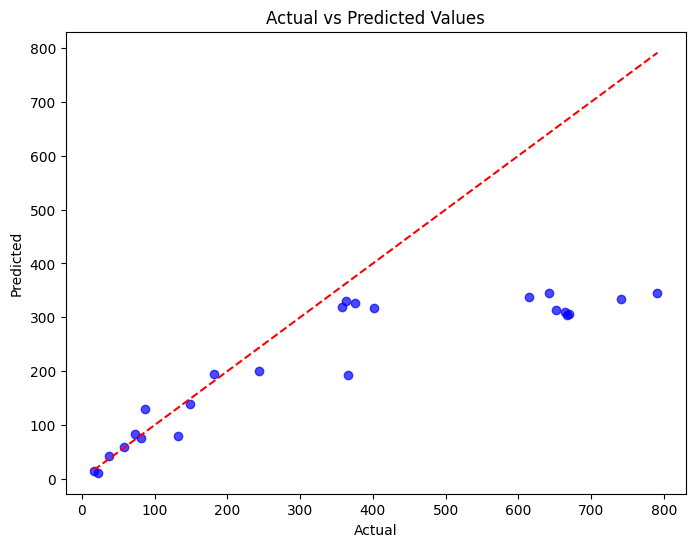

In [66]:
import matplotlib.pyplot as plt

# 绘制实际值与预测值的散点图
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')  # 理想预测线
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Values")
plt.show()


# optimization

In [67]:
from sklearn.model_selection import GridSearchCV

# 定义参数网格
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200]
}

# 初始化 GridSearch
grid_search = GridSearchCV(XGBRegressor(random_state=42), param_grid, scoring='neg_mean_squared_error', cv=3)

# 进行参数搜索
grid_search.fit(X_train, y_train)

# 输出最佳参数
print(f"Best Parameters: {grid_search.best_params_}")


Best Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}


In [68]:
# 使用最佳参数训练模型
best_params = {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}

from xgboost import XGBRegressor
model = XGBRegressor(**best_params, random_state=42)

# 训练模型
model.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = model.predict(X_test)

# 评估模型表现
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred)

print(f"Final Model - MSE: {mse}, RMSE: {rmse}, MAE: {mae}")


Final Model - MSE: 41252.937606143736, RMSE: 203.1081918735523, MAE: 134.90355698267618


# Linear Regression

In [69]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 初始化线性回归模型
lr_model = LinearRegression()

# 训练模型
lr_model.fit(X_train, y_train)

# 在测试集上预测
y_pred_lr = lr_model.predict(X_test)

# 评估模型性能
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = mse_lr ** 0.5
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print(f"Linear Regression - MSE: {mse_lr}, RMSE: {rmse_lr}, MAE: {mae_lr}")


Linear Regression - MSE: 2.7695801977042415e-25, RMSE: 5.262680113501334e-13, MAE: 2.852533024603569e-13


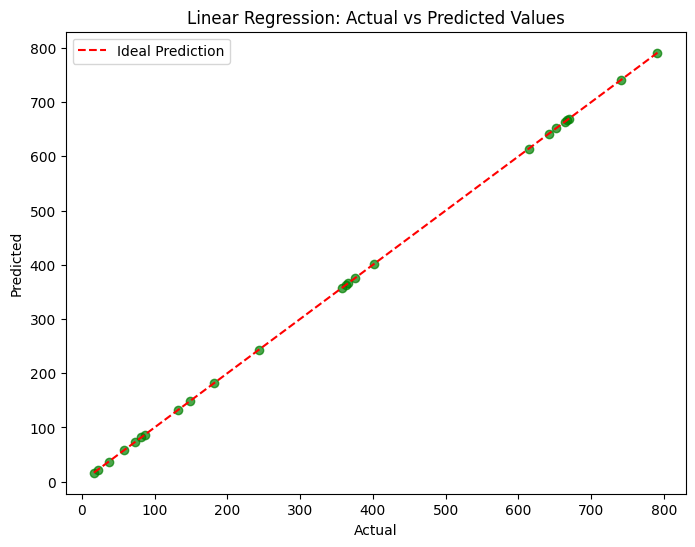

In [70]:
import matplotlib.pyplot as plt

# 绘制散点图
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.7, color="green")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', label='Ideal Prediction')  # 理想预测线
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression: Actual vs Predicted Values")
plt.legend()
plt.show()


In [71]:
# 检查训练集和测试集是否有交集
overlap = set(X_train.index).intersection(set(X_test.index))
print(f"Overlap between train and test: {len(overlap)}")

Overlap between train and test: 0


In [72]:
correlation = X_train.corrwith(y_train)
print(correlation.sort_values(ascending=False))

unique_products_count          0.933527
unique_categories_count        0.880956
Dairy                          0.858673
Meat                           0.687986
Snacks                         0.686443
Butter(550g)                   0.659997
Eggs(1.5dozen)                 0.556199
Sauce                          0.546858
Biscuits                       0.520825
Cupcakes(6pck)                 0.501280
Vegetables                     0.500844
Apples(5pck)                   0.487292
Mushrooms(350g)                0.473275
Bakery                         0.469360
Chicken                        0.464791
Fruits                         0.464416
Eggs(0.5dozen)                 0.445900
Mustard                        0.434085
Strawberry Jam                 0.432233
Chocolates                     0.429135
Grains                         0.426152
Pork                           0.402030
Cookies                        0.400575
Shredded Cheese(620g)          0.373770
Onions(5pck)                   0.370105


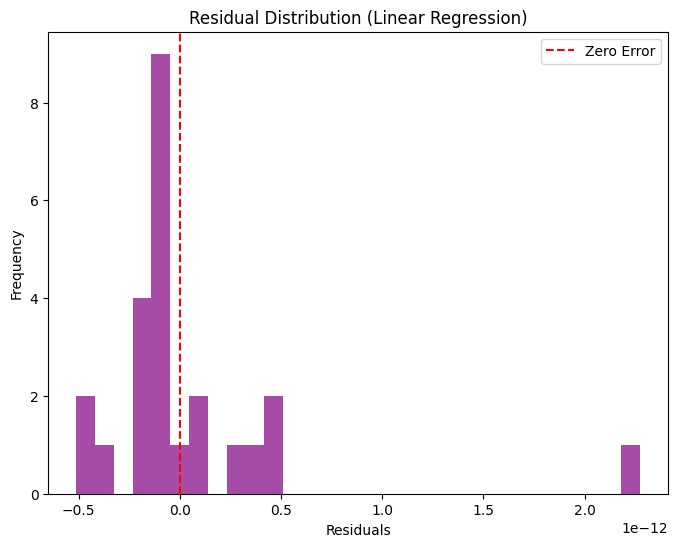

In [73]:
residuals = y_test - y_pred_lr

plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, color="purple", alpha=0.7)
plt.axvline(0, color='red', linestyle='--', label='Zero Error')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution (Linear Regression)")
plt.legend()
plt.show()


# Ridge regression

In [74]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train Ridge regression model with alpha=0.1
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_ridge = ridge_model.predict(X_test_scaled)

# Evaluate the Ridge regression model
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = mse_ridge ** 0.5
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

mse_ridge, rmse_ridge, mae_ridge


(2.703303124397733, 1.644172474042104, 1.0392991688883437)

In [75]:
# Re-run the Ridge regression with full evaluation

# Standardize the features again in case of prior errors
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Ridge regression model
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train_scaled, y_train)

# Predict on the test data
y_pred_ridge = ridge_model.predict(X_test_scaled)

# Evaluate the model
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = mse_ridge ** 0.5
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

# Return the results
mse_ridge, rmse_ridge, mae_ridge


(2.703303124397733, 1.644172474042104, 1.0392991688883437)

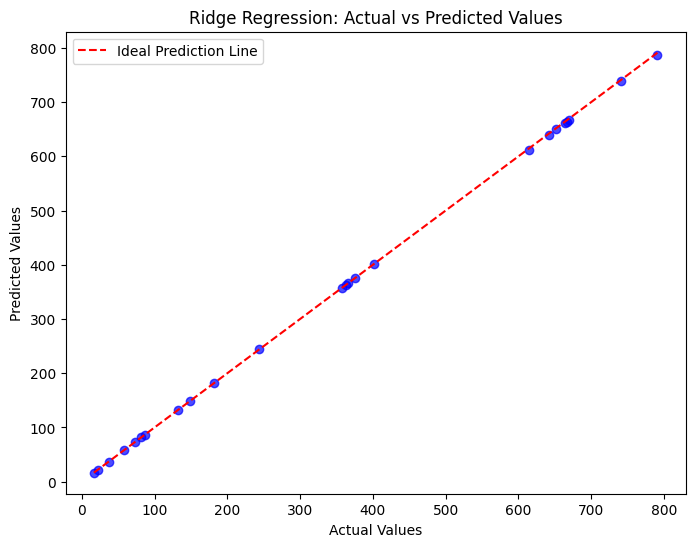

In [76]:
import matplotlib.pyplot as plt

# Visualize the predicted vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ridge, alpha=0.7, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', label='Ideal Prediction Line')  # Ideal line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Ridge Regression: Actual vs Predicted Values")
plt.legend()
plt.show()


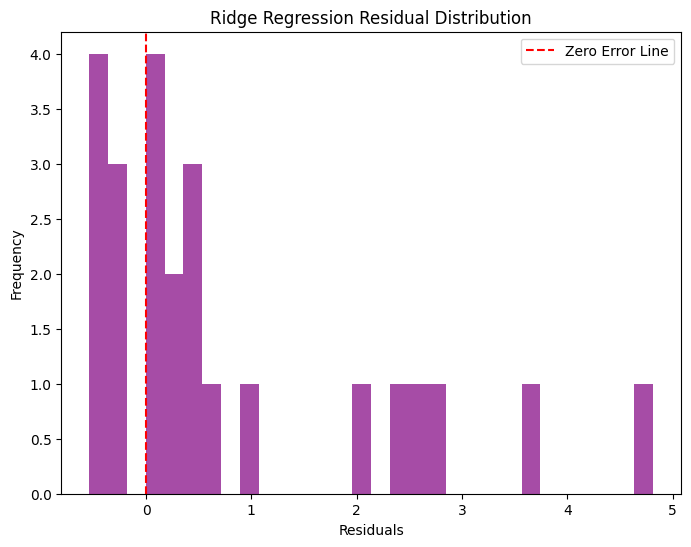

In [77]:
# Visualize residuals
residuals = y_test - y_pred_ridge
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, color="purple", alpha=0.7)
plt.axvline(0, color='red', linestyle='--', label='Zero Error Line')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Ridge Regression Residual Distribution")
plt.legend()
plt.show()
